In [94]:
using ITensors, ITensorMPS, Plots
include("../../data/params.jl")
include("../../data/helpers/saving.jl")
include("../schmidt_spectra/get_spectrum.jl")
include("../schmidt_spectra/deviation/deviation.jl")

   Resolving package versions...
     Project No packages added to or removed from `~/dev/uni/msciproject/Project.toml`
    Manifest No packages added to or removed from `~/dev/uni/msciproject/Manifest.toml`


find_deviation_idx (generic function with 1 method)

In [95]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 10,
                    "MAX_BOND_DIM" => 1000,
                    "ACC" => 10^-16
                    )

run_params_cln = Dict{String, Any}(
    "N" => 40,
    "σ" => 0.00
)

run_params_dis = Dict{String, Any}(
    "N" => 40,
    "σ" => 0.02
)

CURRENT_DIR = @__DIR__
FP = extract_filename_from_system_params(system_params)
MPS_FP = path = joinpath(CURRENT_DIR, "../../data/storage/perturb_$(FP).hd5")
matches_cln = find_runs_by_params(MPS_FP, run_params_cln; load_psi=true, instance_selection=:latest)
matches_dis = find_runs_by_params(MPS_FP, run_params_dis; load_psi=true, instance_selection=:latest)

psi_cln = matches_cln[1].psi
psi_dis = matches_dis[1].psi

40-element MPS:
 ((dim=2|id=204|"S=1/2,Site,n=1") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=2|id=470|"Link,l=1") <Out>
 1: QN("Sz",-1) => 1
 2: QN("Sz",1) => 1)
 ((dim=4|id=459|"Link,l=2") <Out>
 1: QN("Sz",-2) => 1
 2: QN("Sz",0) => 2
 3: QN("Sz",2) => 1, (dim=2|id=121|"S=1/2,Site,n=2") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=2|id=470|"Link,l=1") <In>
 1: QN("Sz",-1) => 1
 2: QN("Sz",1) => 1)
 ((dim=2|id=310|"S=1/2,Site,n=3") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=8|id=653|"Link,l=3") <Out>
 1: QN("Sz",-3) => 1
 2: QN("Sz",-1) => 3
 3: QN("Sz",1) => 3
 4: QN("Sz",3) => 1, (dim=4|id=459|"Link,l=2") <In>
 1: QN("Sz",-2) => 1
 2: QN("Sz",0) => 2
 3: QN("Sz",2) => 1)
 ((dim=2|id=750|"S=1/2,Site,n=4") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=16|id=29|"Link,l=4") <Out>
 1: QN("Sz",-4) => 1
 2: QN("Sz",-2) => 4
 3: QN("Sz",0) => 6
 4: QN("Sz",2) => 4
 5: QN("Sz",4) => 1, (dim=8|id=653|"Link,l=3") <In>
 1: QN("Sz",-3) => 1
 2: QN("Sz",-1) => 3

In [96]:
spec_cln = get_squared_sorted_schmidt_spectrum_from_mps(psi_cln)
spec_dis = get_squared_sorted_schmidt_spectrum_from_mps(psi_dis)

1000-element Vector{Float64}:
 0.23620550531235704
 0.23620550529066692
 0.16114442026962617
 0.16114442022394407
 0.07446227774118741
 0.07446227770587956
 0.02295208527933095
 0.022952085260371298
 0.004601259774528628
 0.0046012597701756055
 ⋮
 1.1060434413562178e-14
 1.1053592118319323e-14
 1.1015216812628377e-14
 1.0963833955117767e-14
 1.0932820381195352e-14
 1.004004067440602e-14
 9.954595078596813e-15
 9.29783855665337e-15
 9.251723097623126e-15

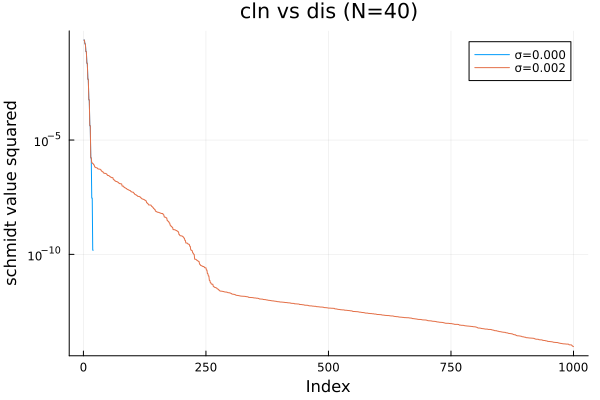

"/Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/clean_vs_disordered_N=40_sigma=0.002_acc=1.0e-16.png"

In [97]:
p_cln_vs_dis = plot(title="cln vs dis (N=40)", yscale=:log10, xlabel="Index", ylabel="schmidt value squared")

plot!(p_cln_vs_dis, 1:length(spec_cln), spec_cln, label="σ=0.000")
plot!(p_cln_vs_dis, 1:length(spec_dis), spec_dis, label="σ=0.002")

display(p_cln_vs_dis)
savefig(p_cln_vs_dis, joinpath(CURRENT_DIR, "clean_vs_disordered_N=40_sigma=0.002_acc=1.0e-16.png"))

In [98]:
ξ = inner(psi_cln, psi_dis)

0.9999730454595684

In [99]:
psi_r = psi_dis - ξ * psi_cln
normalize!(psi_r)


40-element MPS:
 ((dim=2|id=204|"S=1/2,Site,n=1") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=4|id=34|"Link,l=1") <Out>
 1: QN("Sz",-1) => 2
 2: QN("Sz",1) => 2)
 ((dim=2|id=121|"S=1/2,Site,n=2") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=7|id=984|"Link,l=2") <Out>
 1: QN("Sz",-2) => 2
 2: QN("Sz",0) => 3
 3: QN("Sz",2) => 2, (dim=4|id=34|"Link,l=1") <In>
 1: QN("Sz",-1) => 2
 2: QN("Sz",1) => 2)
 ((dim=2|id=310|"S=1/2,Site,n=3") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=12|id=942|"Link,l=3") <Out>
 1: QN("Sz",-3) => 2
 2: QN("Sz",-1) => 4
 3: QN("Sz",1) => 4
 4: QN("Sz",3) => 2, (dim=7|id=984|"Link,l=2") <In>
 1: QN("Sz",-2) => 2
 2: QN("Sz",0) => 3
 3: QN("Sz",2) => 2)
 ((dim=2|id=750|"S=1/2,Site,n=4") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=21|id=960|"Link,l=4") <Out>
 1: QN("Sz",-4) => 2
 2: QN("Sz",-2) => 5
 3: QN("Sz",0) => 7
 4: QN("Sz",2) => 5
 5: QN("Sz",4) => 2, (dim=12|id=942|"Link,l=3") <In>
 1: QN("Sz",-3) => 2
 2: QN("Sz",-1) => 

┌ Info: Sum: 1.0000000000000009
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sZmlsZQ==.jl:3


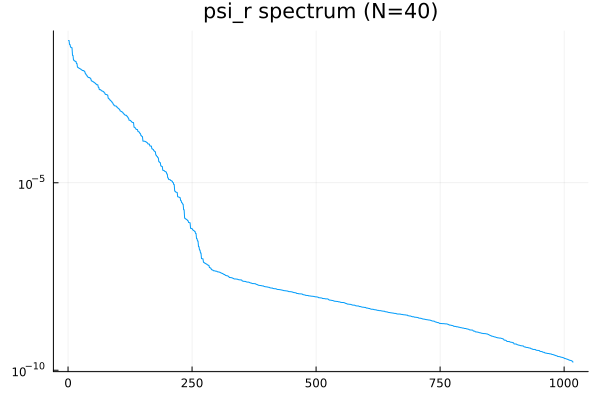

In [100]:
spec_r = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)

@info "Sum: $(sum(spec_r))"

p3 = plot(1:length(spec_r), spec_r, title="psi_r spectrum (N=40)",yscale=:log10, legend=false)

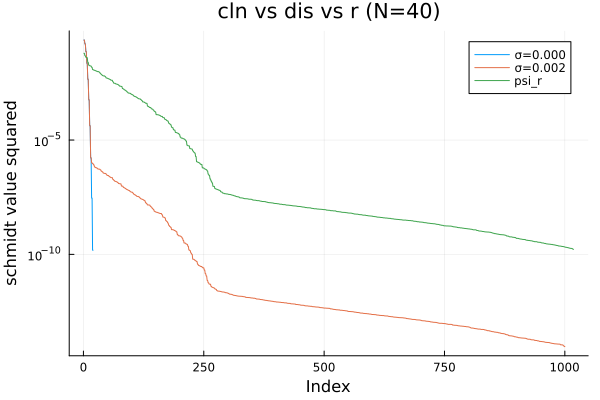

"/Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/clean_vs_disordered_N=40_sigma=0.002_acc=1.0e-16.png"

In [101]:
p_cln_vs_dis_vs_r = plot(title="cln vs dis vs r (N=40)", yscale=:log10, xlabel="Index", ylabel="schmidt value squared")

plot!(p_cln_vs_dis_vs_r, 1:length(spec_cln), spec_cln, label="σ=0.000")
plot!(p_cln_vs_dis_vs_r, 1:length(spec_dis), spec_dis, label="σ=0.002")
plot!(p_cln_vs_dis_vs_r, 1:length(spec_r), spec_r, label="psi_r")

display(p_cln_vs_dis_vs_r)
savefig(p_cln_vs_dis_vs_r, joinpath(CURRENT_DIR, "clean_vs_disordered_N=40_sigma=0.002_acc=1.0e-16.png"))

# With disorder

In [ ]:
# we can load in a set of data points



sigma_vals = vcat(0.0001:0.00005:0.002)
N = 40
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 10,
                    "MAX_BOND_DIM" => 1000,
                    "ACC" => 10^-16
                    )

CURRENT_DIR = @__DIR__
base_fp = extract_filename_from_system_params(system_params)

sigma_to_psi = Dict{Float64, Tuple{MPS, MPS}}()
# stores (cln, dis)

for sigma in sigma_vals
    rp_cln = Dict{String, Any}(
        "N" => N,
        "σ" => 0.00
    )
    rp_dis = Dict{String, Any}(
        "N" => N,
        "σ" => sigma
    )
    fp = joinpath(CURRENT_DIR, "../../data/storage/perturb_sigma_$(sigma)_$(FP).hd5")
    cln = find_runs_by_params(fp, rp_cln; load_psi=true, instance_selection=:latest)[1].psi
    dis = find_runs_by_params(fp, rp_dis; load_psi=true, instance_selection=:latest)[1].psi

    sigma_to_psi[sigma] = (cln, dis)
end

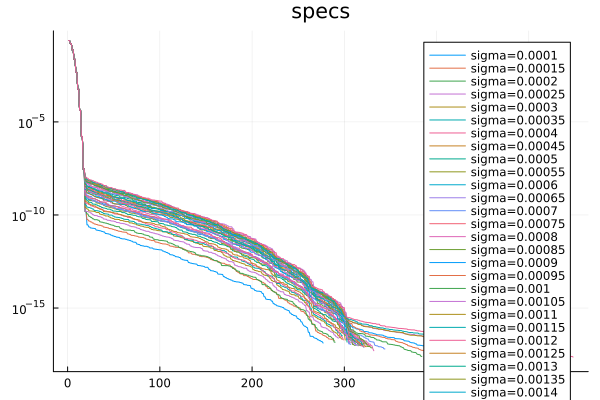

In [138]:
# lets just plot all of these on the graph to see what they look like

sorted_pairs = sort(collect(sigma_to_psi), by=x->x[1])

p_ss = plot(title="specs", yscale=:log10)

for (sigma, (cln, dis)) in sorted_pairs
    # plot!(1:length(cln), cln, label="cln sigma=$sigma")
    dis_spec = get_squared_sorted_schmidt_spectrum_from_mps(dis)
    plot!(1:length(dis_spec), dis_spec, label="sigma=$sigma")
end

display(p_ss)



6.283153997088675e-10
1.4126458891539073e-9
2.5418931404175282e-9
4.05416877846676e-9
5.940420377825717e-9
7.705327487173008e-9
1.0660055060895957e-8
1.2141693206402238e-8
1.523220638510736e-8
2.2187618631264172e-8
2.3084924860583556e-8
2.6652677509453326e-8
3.355340083555092e-8
3.201570109023777e-8
3.951318916506352e-8
4.5913465918090424e-8
5.043064787990659e-8
5.685008053202267e-8
6.769020510777324e-8
6.587362189058865e-8
7.29835598622941e-8
8.316543542719046e-8
9.600297545819814e-8
9.567549086320071e-8
1.064222593383235e-7
1.0364329694478869e-7
1.1424592205599993e-7
1.360387277271613e-7
1.631662072121287e-7
1.5545679321604666e-7
1.60294144513351e-7
1.7359377646464225e-7
2.0052531679581875e-7
1.9393822747737488e-7
1.8207504115519413e-7
2.169462273160505e-7
2.2261217924590682e-7
2.3011344296719471e-7
2.5241335832593137e-7


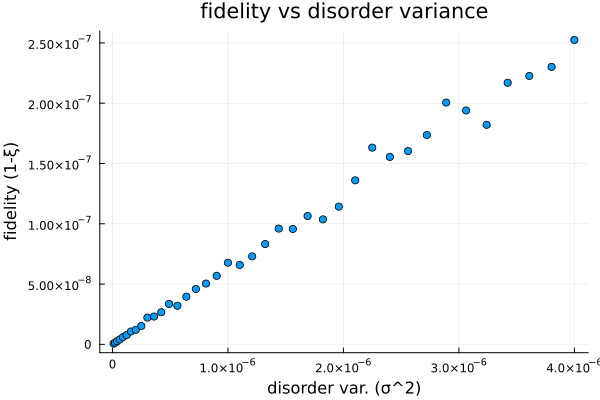

In [140]:
# now calc inner vs sigma^2 (variance)
fidelity(a, b) = 1 - abs(inner(a, b))

fidelities = []
sigmas = []
for (sigma, (cln, dis)) in sorted_pairs
    fid = fidelity(cln, dis)
    println(fid)
    push!(sigmas, sigma^2)
    push!(fidelities, fid)
end

p_overlap = scatter(sigmas, fidelities, title="fidelity vs disorder variance", xlabel="disorder var. (σ^2)", ylabel="fidelity (1-ξ)", legend=false)

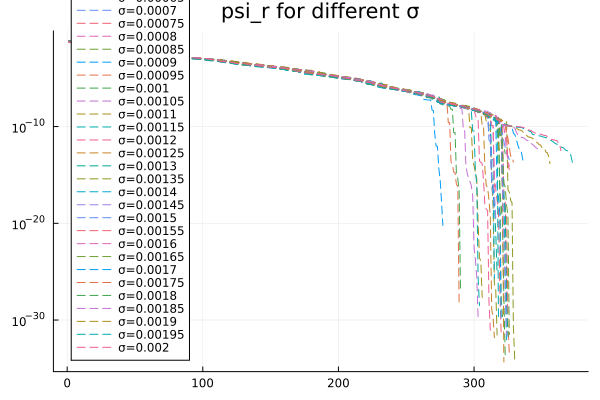

In [124]:
function get_psi_r(cln, dis)
    ξ = inner(cln, dis)
    psi_r = dis - ξ * cln
    return normalize!(psi_r)
end

p_psi_rs = plot(title="psi_r for different σ", yscale=:log10, legend=:bottomleft)

for (sigma, (cln, dis)) in sorted_pairs
    pr = get_psi_r(cln, dis)
    s = get_squared_sorted_schmidt_spectrum_from_mps(pr)
    plot!(p_psi_rs, 1:length(s), s, label="σ=$sigma", linestyle=:dash)
end

display(p_psi_rs)


In [166]:

sigma_to_psis=Dict{Float64, Tuple{Vector{MPS}, Vector{MPS}}}()
# looks like sigma => (cln_mpss, dis_mpss)

for sigma in sigma_vals
    rp_cln = Dict{String, Any}(
        "N" => N,
        "σ" => 0.00
    )
    rp_dis = Dict{String, Any}(
        "N" => N,
        "σ" => sigma
    )
    fp = joinpath(CURRENT_DIR, "../../data/storage/perturb_sigma_$(sigma)_$(FP).hd5")
    cln_rns = find_runs_by_params(fp, rp_cln; load_psi=true, instance_selection=:all)
    dis_rns = find_runs_by_params(fp, rp_dis; load_psi=true, instance_selection=:all)

    cln_psis = [c.psi for c in cln_rns if c.psi != nothing]
    dis_psis = [d.psi for d in dis_rns if d.psi != nothing]

    sigma_to_psis[sigma] = (cln_psis, dis_psis)
end

┌ Info: σ = 0.0001 had 5 instances, with mean: 6.167069521723079e-10, error: 7.841544607263376e-12
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:17
┌ Info: σ = 0.00015 had 3 instances, with mean: 1.4491006542864209e-9, error: 2.8401613263940035e-11
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:17
┌ Info: σ = 0.0002 had 3 instances, with mean: 2.5306129784278633e-9, error: 5.708865117452798e-12
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:17
┌ Info: σ = 0.00025 had 3 instances, with mean: 3.760276460577454e-9, error: 1.4998568860999706e-10
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:17
┌ Info: σ = 0.0003 had 3 instances, w

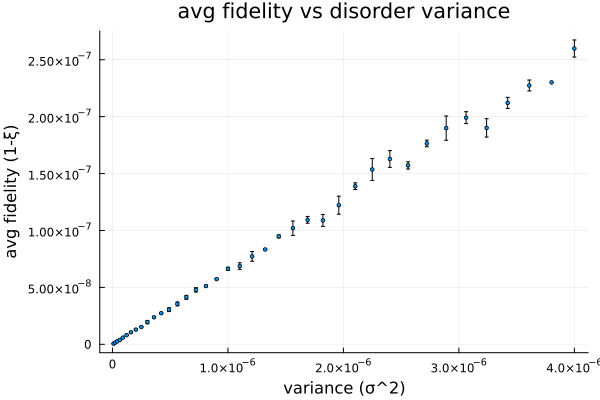

In [167]:
using Statistics, StatsBase

sorted_pairs_pl = sort(collect(sigma_to_psis), by=x->x[1])

avg_fidelities = Float64[]
err_fidelities = Float64[]
sigma_vars = Float64[]

for (sigma, (clns, diss)) in sorted_pairs_pl
    # calculate fidelity for every instance pair at this sigma
    fids = [fidelity(c, d) for (c, d) in zip(clns, diss)]

    avg_f = mean(fids)
    err_f = sem(fids)
    if err_f == NaN err_f = 0 end

    @info "σ = $sigma had $(length(fids)) instances, with mean: $avg_f, error: $err_f"

    push!(avg_fidelities, avg_f)
    push!(err_fidelities, err_f)
    push!(sigma_vars, sigma^2)

end

p_fid = scatter(sigma_vars, avg_fidelities,
                yerror=err_fidelities,
                title="avg fidelity vs disorder variance",
                xlabel="variance (σ^2)",
                ylabel="avg fidelity (1-ξ)",
                legend=false,
                markersize=2,
                markerstrokewidth=1)


In [168]:
using GLM, DataFrames

err_fidelities_clean = replace(err_fidelities, NaN => 0.0)

weights = [e > 0 ? 1/e^2 : 1.0 for e in err_fidelities_clean]

valid_weights = [1/e^2 for e in err_fidelities_clean if e > 0]
default_weight = isempty(valid_weights) ? 1.0 : median(valid_weights)

final_weights = [e > 0 ? 1/e^2 : default_weight for e in err_fidelities_clean]

df = DataFrame(X = sigma_vars, Y = avg_fidelities)

# fit (and force through 0 for this)
model = lm(@formula(Y ~ 0 + X), df, wts=final_weights)

# Extract results
gradient = coef(model)[1]
grad_err = stderror(model)[1]

println("Gradient: $gradient ± $grad_err")

Gradient: 0.06311860593348001 ± 3.658961495543989e-15


┌ Info: Processing N = 20
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X22sZmlsZQ==.jl:15
┌ Info: Processing N = 30
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X22sZmlsZQ==.jl:15
┌ Info: Processing N = 40
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X22sZmlsZQ==.jl:15
┌ Info: Processing N = 50
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X22sZmlsZQ==.jl:15
┌ Info: Processing N = 60
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X22sZmlsZQ==.jl:15


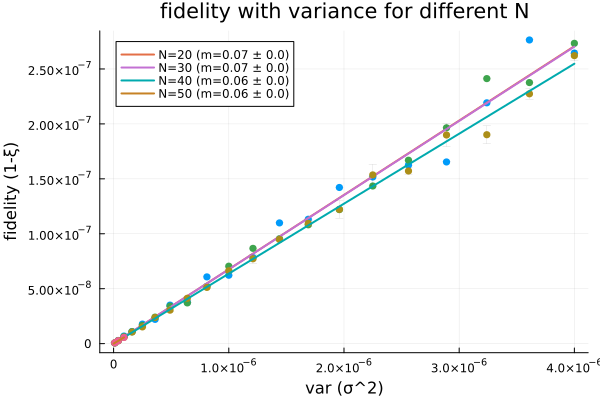

In [ ]:
using ITensors, ITensorMPS, Plots
using Statistics, StatsBase, GLM, DataFrames

N_vals = 20:10:60
sigma_vals = 0.0001:0.0001:0.002
accuracies = [10^-16]

p_master = plot(title="fidelity with variance for different N",
                xlabel="var (σ^2)",
                ylabel="fidelity (1-ξ)",
                legend=:topleft)

# --- Main Analysis Loop ---
for (i, N) in enumerate(N_vals)
    @info "Processing N = $N"

    # Vectors to store results for this specific N
    avg_fids = Float64[]
    err_fids = Float64[]
    sig_vars = Float64[]

    for sigma in sigma_vals
        # 1. Setup paths and params (Matching your notebook logic)
        system_params = Dict{String,Any}(
            "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
            "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
        )
        fp_suffix = extract_filename_from_system_params(system_params)
        fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(sigma)_$(fp_suffix).hd5")

        # 2. Load all instances
        cln_rns = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:all)
        dis_rns = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>sigma); load_psi=true, instance_selection=:all)

        if !isempty(cln_rns) && !isempty(dis_rns)
            fids = [fidelity(c.psi, d.psi) for (c, d) in zip(cln_rns, dis_rns)]

            push!(avg_fids, mean(fids))
            push!(err_fids, length(fids) > 1 ? sem(fids) : 0.0)
            push!(sig_vars, sigma^2)
        end
    end

    if length(avg_fids) > 1

        wts = [e > 0 ? 1/e^2 : 1.0 for e in err_fids]

        df = DataFrame(X = sig_vars, Y = avg_fids)
        model = lm(@formula(Y ~ 0 + X), df, wts=wts)

        gradient = coef(model)[1]
        grad_err = stderror(model)[1]

        label_str = "N=$N (m=$(round(gradient, digits=2)) ± $(round(grad_err, digits=2)))"

        scatter!(p_master, sig_vars, avg_fids, yerror=err_fids, label=false, markerstrokewidth=0, color=i)

        plot!(p_master, x -> gradient * x, 0, maximum(sig_vars),
              label=label_str, lw=2, linestyle=:dash, color=i)
    end
end

display(p_master)
# savefig(p_master, "fidelity_scaling_N_sweep.png")